In [1]:
import glob
from astropy.io import fits
import numpy as np
import pandas as pd
import montage_wrapper as montage
import os.path
import pdb
import matplotlib.pyplot as plt
import sys

sys.path.insert(1, '/mnt/disk3/ngc1277/feb24') # caution: path[0] is reserved for script path (or '' in REPL)
from my_python_library_v5 import resistant_mean

In [ ]:
image_filename = "/mnt/disk3/euclid/dario_2024/lsb_optimized_jan25/EUC_VIS_LSB_ObsID_2706.fits"
side_pix = 599
x0 = 35650
y0 = 23324
bckg_name = "bckg_VIS.fits"
segmentation_name = "segmentation_VIS.fits"
galaxy_ground_truth = "galaxy_convolved_1000_0.05_VIS_with_cosmo_dim.fits"
stream_ground_truth = "stream_convolved_1000_0.05_VIS_with_cosmo_dim.fits"

In [4]:
montage.mSubimage_pix(image_filename, bckg_name, x0-(side_pix/2), y0-(side_pix/2), side_pix)
#os.system(f"astcrop {image_filename} -h0 --center={x0},{y0} --width={side_pix} --mode=img -o {bckg_name}")

hdu = fits.open(bckg_name)
tmp = hdu[0].data
tmp_hdr = hdu[0].header
tmp = tmp[:-1,:-1]
tmp_hdr["NAXIS1"] = side_pix
tmp_hdr["NAXIS2"] = side_pix
fits.writeto(bckg_name,tmp,tmp_hdr,overwrite=True)

In [5]:
hdu = fits.open(bckg_name)
bckg = hdu[0].data
bckg_hdr = hdu[0].header

hdu = fits.open(galaxy_ground_truth)
galaxy = hdu[1].data
hdu = fits.open(stream_ground_truth)
stream = hdu[1].data

hdu = fits.open(segmentation_name)
seg = hdu[0].data.astype(float)
zeros = seg == 0
objs  = seg != 0
seg[zeros] = 1.
seg[objs]  = float("NaN")

img = (bckg+galaxy+stream) * seg

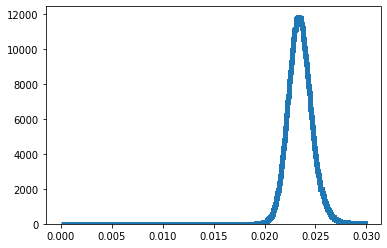

In [6]:
num_eles,edges_hist,patches_hist=plt.hist(img.flatten(),
            bins=np.arange(0.,0.03,0.0001),
            histtype="step",linewidth=5,label=None)

In [7]:
mean_whole_img, stddev_whole_img, stddev_of_the_mean_whole_img = resistant_mean(img, 3)
print(-2.5*np.log10(stddev_whole_img)+30.132+5*np.log10(0.1))
print(-2.5*np.log10(stddev_whole_img)+30.132)
print(mean_whole_img)
print(stddev_whole_img)

32.50544494212602
37.50544494212602
0.023441243761709675
0.0011236266292237508


66.50615 2.008483


/tmp/ipykernel_12015/28351124.py:19: RuntimeWarning: invalid value encountered in log10
  im = ax.imshow(-2.5*np.log10(individual_img)+30.132+(5*np.log10(0.1)), origin="lower", cmap="viridis", interpolation="none")


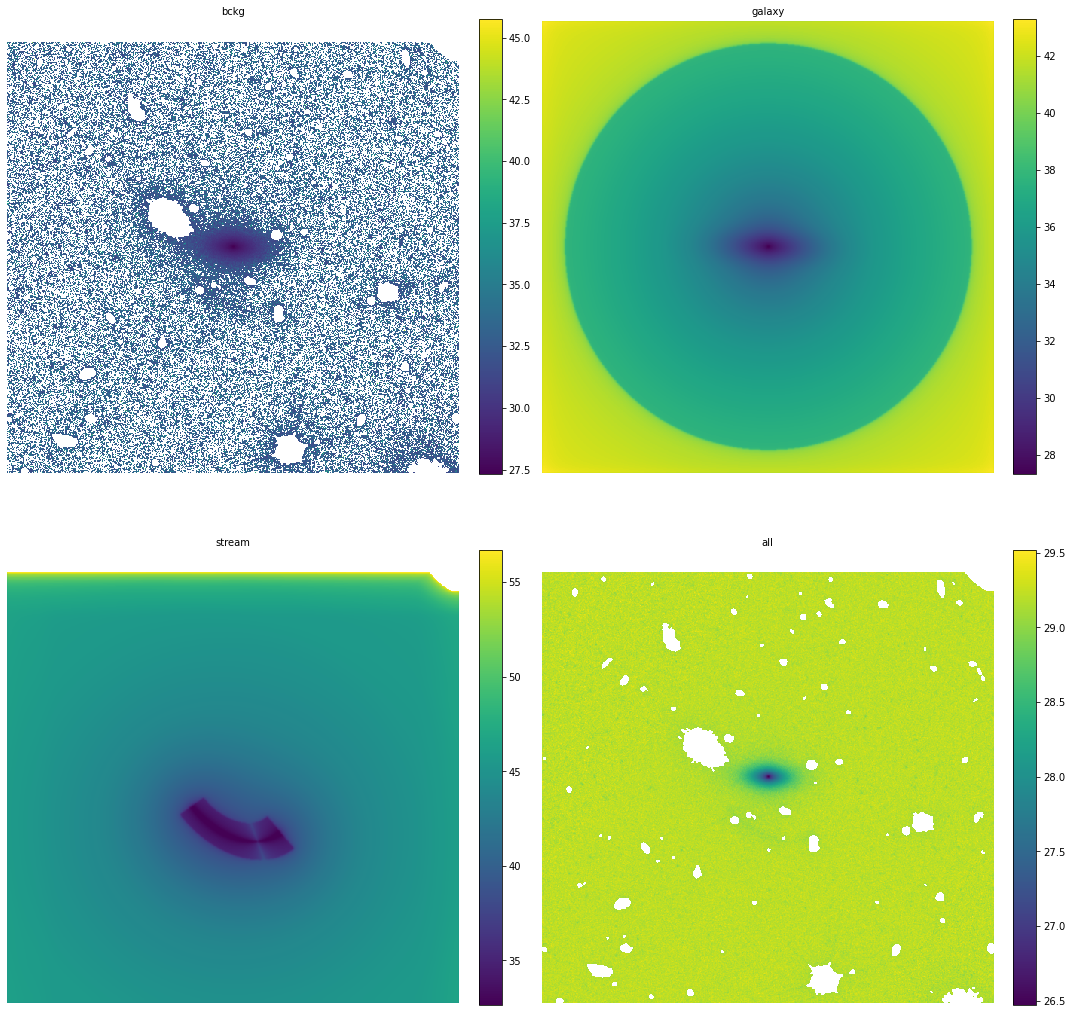

In [8]:
hdu = fits.open(galaxy_ground_truth)
galaxy = hdu[1].data
hdu = fits.open(stream_ground_truth)
stream = hdu[1].data

images = []
images.append(img-0.023441243761709675)
images.append(galaxy)
images.append(stream)
print(np.nansum(galaxy), np.nansum(stream))
images.append(img+galaxy+stream)
files = ["bckg", "galaxy", "stream", "all"]

# Plot side by side
fig, axes = plt.subplots(2, 2, figsize=(15,15))
axes = axes.flatten()

for ax, individual_img, name in zip(axes, images, files):
    im = ax.imshow(-2.5*np.log10(individual_img)+30.132+(5*np.log10(0.1)), origin="lower", cmap="viridis", interpolation="none")
    ax.set_title(name, fontsize=10)
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # <- add colorbar

fits.writeto("kk.fits",img+galaxy+stream-0.023370890542073888,overwrite=True)

plt.tight_layout()
plt.show()

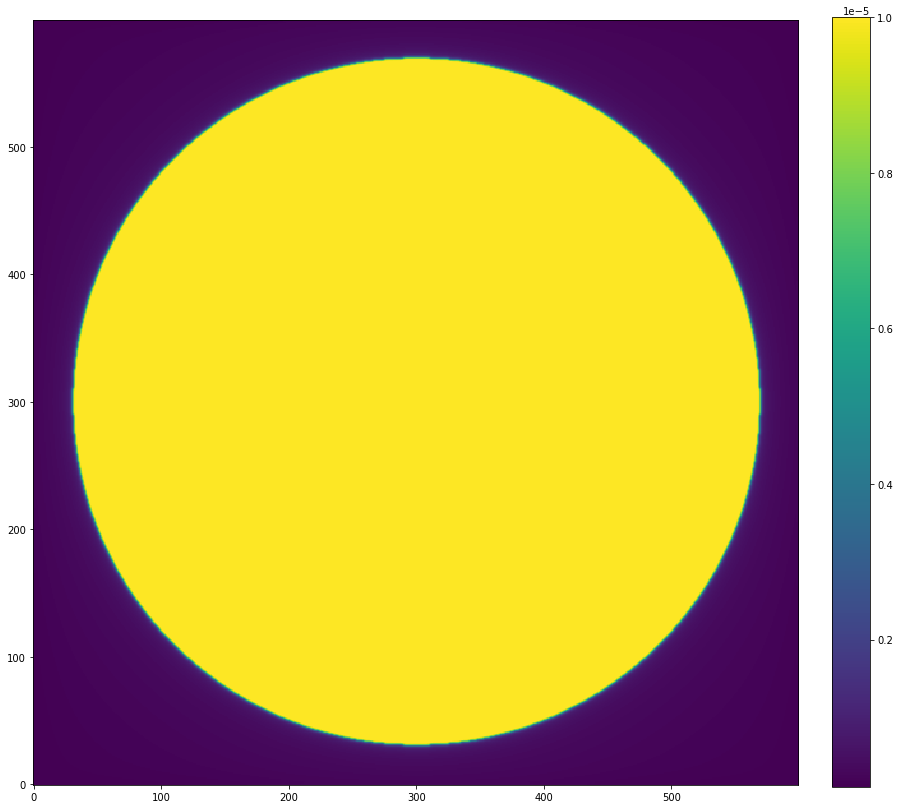

In [15]:
hdu = fits.open("conv_gnuastro.fits")
gal = hdu[1].data
fig, ax = plt.subplots(1,1, figsize=(15,15))
im = ax.imshow(gal,interpolation="none",origin="lower", cmap="viridis", vmax=1e-5, vmin=1e-7)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # <- add colorbar